**Import packages and dependecies**

In [1]:
%pip install -q -e ..

Note: you may need to restart the kernel to use updated packages.


ERROR: file:///C:/Users/tcphan/OneDrive/Documents/Data%20Science%20Projects/topological does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [16]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import kagglehub

from tda.rips import VietorisRips
from tda.bottleneck import bottleneck_distance
from tda.plotting import plot_persistence_diagram

### 1. Load in data inputs

The dataset shown below is from the Digital Payment Fraud Detection Benchmark which contains simulated, large-scale digital payment transaction data. The data spans one full calendar year with a known feature drift occurring mid-year. We will use this data to see how TDA can be applied to detect this feature drift

**Months 1-6**
- Merchant-driven fraud influence
- Risk primarily influenced by merchant and IP-level signals

**Months 7-12**
- Increased velocity-based fraud
- Low-amount micro-transactions
- Higher sensitivity to international activity

For further information about the data, see [Digital Payment Fraud Detection Benchmark](https://www.kaggle.com/datasets/rohit8527kmr7518/digital-payment-fraud-detection-benchmark?select=transactions_train.csv).

In [3]:
# Download data fram Kaggle
path = kagglehub.dataset_download("rohit8527kmr7518/digital-payment-fraud-detection-benchmark")

# Train contains all transactions for months 1-6
transactions_train_df = pl.read_csv(f"{path}/transactions_train.csv")
# Test contains all transactions for months 7-12
transactions_test_df = pl.read_csv(f"{path}/transactions_test.csv")

# Show transactions
transactions_train_df.limit(50).show()

transaction_id,transaction_time,customer_id,merchant_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,payment_channel,device_type,is_international,ip_risk_score,txn_count_1h,txn_count_24h,failed_txn_count_24h,geo_distance_from_last_txn,amount_deviation_from_user_mean,is_fraud,post_auth_risk_score
i64,str,i64,i64,i64,i64,i64,f64,f64,f64,str,str,i64,f64,i64,i64,i64,f64,f64,i64,f64
359131,"""2023-01-01 00:02:00.328105993""",11102,2282,284,2,3,6091.747132,0.456269,2408.320473,"""wallet""","""desktop""",0,0.142532,1,3,1,33.458018,2205.262235,0,0.09992
351207,"""2023-01-01 00:02:26.339769237""",22891,3016,1363,2,3,3794.044563,0.449021,2765.255095,"""bank_transfer""","""mobile""",0,0.131811,0,5,0,3.375083,2638.786943,0,0.291715
10209,"""2023-01-01 00:06:54.145825305""",3102,1855,1318,5,2,6697.058451,0.220252,1529.079168,"""card""","""desktop""",0,0.322137,0,5,0,13.732603,1305.843886,0,0.216647
62660,"""2023-01-01 00:06:57.723185583""",4041,2525,1914,1,1,2906.711704,0.202223,610.407487,"""card""","""mobile""",0,0.171764,1,2,0,18.840187,513.517097,0,0.354154
384254,"""2023-01-01 00:08:05.487541188""",3979,1555,360,2,3,5082.651983,0.17123,986.397163,"""card""","""mobile""",0,0.248766,1,1,0,15.344375,816.97543,0,0.149084


Limit to features fields (remove any primary keys or identifier fields).

In [4]:
primary_keys_list = [
    "transaction_id",
    "transaction_time",
    "customer_id",
    "merchant_id",
]

target_outcomes_list = [
    "is_fraud",
    "post_auth_risk_score",
]

features_list = [
    "account_age_days",
    "credit_score_band",
    "kyc_level",
    "avg_monthly_spend",
    "merchant_risk_score",
    "transaction_amount",
    "payment_channel",
    "device_type",
    "is_international",
    "ip_risk_score",
    "txn_count_1h",
    "txn_count_24h",
    "failed_txn_count_24h",
    "geo_distance_from_last_txn",
    "amount_deviation_from_user_mean",
]

preprocessed_train_df = transactions_train_df.select(features_list)
preprocessed_test_df = transactions_test_df.select(features_list)

print(f"Total # of features: {len(features_list)}")

Total # of features: 15


Remove columns if they have high missingness rate.

In [5]:
combined_df = pl.concat([preprocessed_train_df, preprocessed_test_df])

# Initialize parameters
columns_list = combined_df.columns
tot_n_rows = combined_df.shape[0]
missing_threshold = 0.4 # Columns w/ missing rate less than or equal to threshold are kept

# Calculate the percent of missing in each column
missing_count_df = combined_df.null_count()/tot_n_rows
missing_count_df = missing_count_df.unpivot(
    on=columns_list,
    variable_name="Variable Name",
    value_name="p_missing"
)

# Remove columns from data
columns_failed_threshold_list = missing_count_df.filter(pl.col("p_missing") > missing_threshold).select("Variable Name").to_series()
preprocessed_train_df = preprocessed_train_df.select([c for c in columns_list if c not in columns_failed_threshold_list])
preprocessed_test_df = preprocessed_test_df.select([c for c in columns_list if c not in columns_failed_threshold_list])

print(f"Total # of columns removed due to high missing rate: {len(columns_failed_threshold_list)}")

Total # of columns removed due to high missing rate: 0


Apply label encoding to all string data type columns.

In [6]:
# List of all string type columns
string_dtype_list = [
    name for name, dtype in preprocessed_train_df.schema.items() if dtype == pl.String
]

# Apply label encoding to convert string to integer format
for colname in string_dtype_list:
    preprocessed_train_df = preprocessed_train_df.with_columns(
        pl.col(colname).cast(pl.Categorical).to_physical().alias(f"{colname}_indexed")
    )
    preprocessed_test_df = preprocessed_test_df.with_columns(
        pl.col(colname).cast(pl.Categorical).to_physical().alias(f"{colname}_indexed")
    )

print(f"Total # of string features requiring label encoding: {len(string_dtype_list)}")
preprocessed_train_df.select(
    string_dtype_list + [f"{colname}_indexed" for colname in string_dtype_list]
).show()

# Remove the original string data type features, keep only the label encoded version
preprocessed_train_df = preprocessed_train_df.drop(*string_dtype_list)
preprocessed_test_df = preprocessed_test_df.drop(*string_dtype_list)

Total # of string features requiring label encoding: 2


payment_channel,device_type,payment_channel_indexed,device_type_indexed
str,str,u32,u32
"""wallet""","""desktop""",0,0
"""bank_transfer""","""mobile""",1,1
"""card""","""desktop""",2,0
"""card""","""mobile""",2,1
"""card""","""mobile""",2,1


### 2. Compare Rips simplices and persistence diagrams

We start by calculating the Vietoris Rips simplices for the time period "Months 1-6" and "Months 7-12". Due to the large size of the data, calculating the Rips simplices for all observations can take a long time. As such, to reduce computation time, we take a random subsample of the data to evaluate the Rips simplices.

In [19]:
n_dimensions = 2 # Number of dimensions to calculate simplices for
max_epsilon = 50.0 # The maximum distance between each data point to consider
sample_size = 25000 # Number of observations to randomly sample

# Calculate Rips simplices
rips_config_train = VietorisRips(max_dim=n_dimensions, max_epsilon=max_epsilon)
rips_config_train.fit_transform(preprocessed_train_df.sample(n=sample_size, seed=42))

rips_config_test = VietorisRips(max_dim=n_dimensions, max_epsilon=max_epsilon)
rips_config_test.fit_transform(preprocessed_test_df.sample(n=sample_size, seed=42))

    
print(f"\nTime Period: Months 1-6")
print("-"*100)

for i in range(n_dimensions+1):
    print(f"# of simplices for {i}-th dimension: {len(rips_config_train.get_simplices_for_dim(dim=i)):,}")

print(f"\nTime Period: Months 7-12")
print("-"*100)

for i in range(n_dimensions+1):
    print(f"# of simplices for {i}-th dimension: {len(rips_config_test.get_simplices_for_dim(dim=i)):,}")



Time Period: Months 1-6
----------------------------------------------------------------------------------------------------
# of simplices for 0-th dimension: 25,000
# of simplices for 1-th dimension: 818
# of simplices for 2-th dimension: 7

Time Period: Months 7-12
----------------------------------------------------------------------------------------------------
# of simplices for 0-th dimension: 25,000
# of simplices for 1-th dimension: 843
# of simplices for 2-th dimension: 11


Plot the persistence diagrams to visualize differences between "Months 1-6" and "Months 7-12" time period.


Time Period: Months 1-6
----------------------------------------------------------------------------------------------------


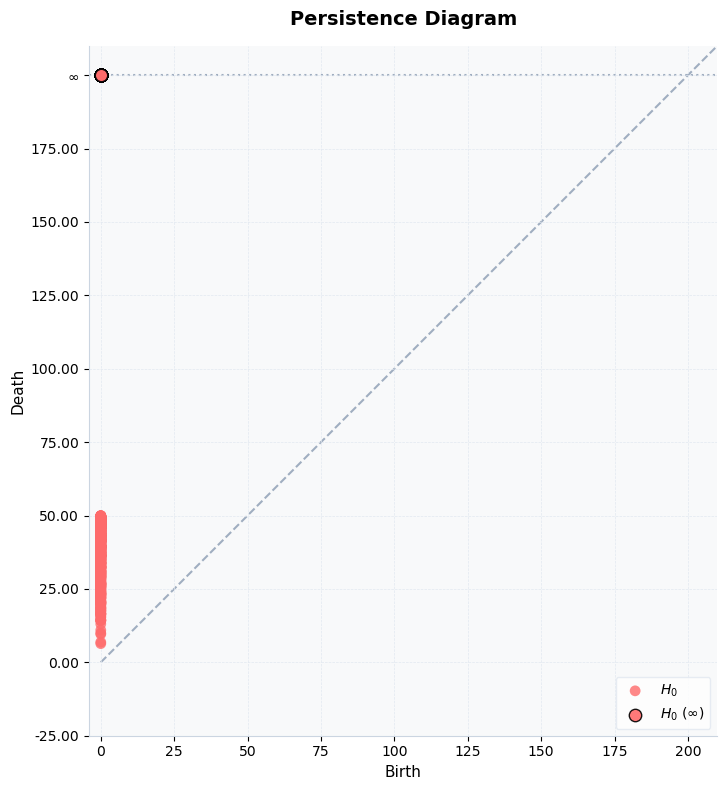


Time Period: Months 7-12
----------------------------------------------------------------------------------------------------


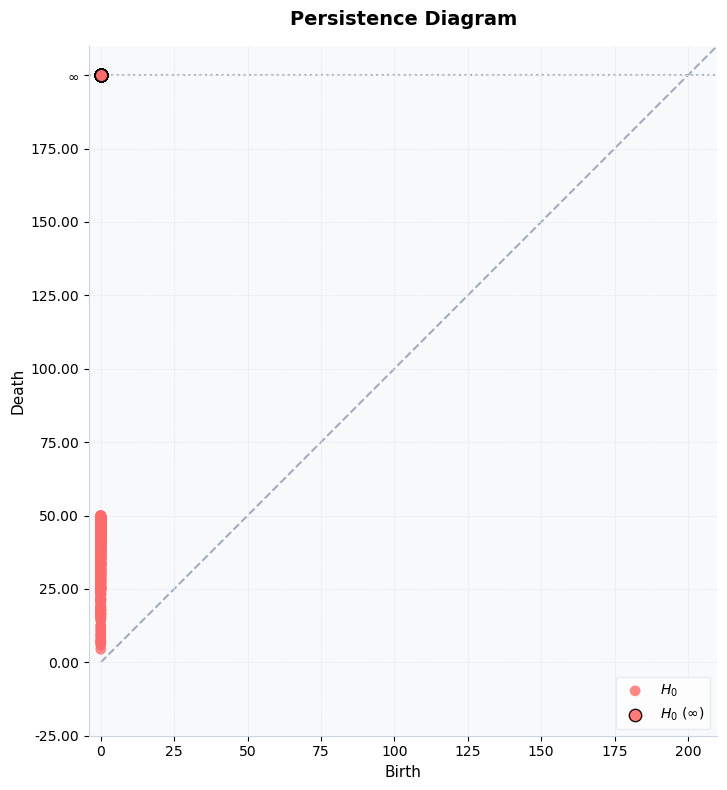

In [30]:
print(f"\nTime Period: Months 1-6")
print("-"*100)

# Calculate birth-death pairs
birth_death_by_dimension_train = rips_config_train.compute_birth_death_pairs()

# Plot a persistence plot showcasing the birth and death time of each simplex in each dimension
fig, ax = plt.subplots(figsize=(8, 8)) 
plot_persistence_diagram(birth_death_by_dimension_train, max_limit=200, ax=ax, show=False)
plt.show()

print(f"\nTime Period: Months 7-12")
print("-"*100)

# Calculate birth-death pairs
birth_death_by_dimension_test = rips_config_test.compute_birth_death_pairs()

# Plot a persistence plot showcasing the birth and death time of each simplex in each dimension
fig, ax = plt.subplots(figsize=(8, 8)) 
plot_persistence_diagram(birth_death_by_dimension_test, max_limit=200, ax=ax, show=False)
plt.show()

Calculate the bottleneck distance to determine how far apart the two persistence diagrams are from one another.

In [31]:
# Convert to list of tuples format
birth_death_pairs_list_train = [pair for pairs_list in birth_death_by_dimension_train.values() for pair in pairs_list if pair[1] != np.inf]
birth_death_pairs_list_test =  [pair for pairs_list in birth_death_by_dimension_test.values() for pair in pairs_list if pair[1] != np.inf]

# Calculate bottleneck distance
distance = bottleneck_distance(diagram_a=birth_death_pairs_list_train, diagram_b=birth_death_pairs_list_test)
print(f"Bottleneck distance: {distance}")

Bottleneck distance: 24.916685672058065
